# Análisis CodeQL — Vulnerabilidades Estáticas

CodeQL analiza el código fuente de cada repositorio en busca de patrones de
vulnerabilidades conocidas (inyección SQL, XSS, SSRF, path traversal, etc.).
Los hallazgos se clasifican por regla, CWE y severidad.

**Lenguajes soportados:** Python, JavaScript/TypeScript, Java/Kotlin, C#, Go, Ruby, Swift, C/C++

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DB_PATH = os.getenv("DB_PATH", "/data/secpipeline.json")
if not Path(DB_PATH).exists():
    DB_PATH = str(Path("../data/secpipeline.json").resolve())

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

SEV_ORDER   = ["high", "medium", "low", "unknown"]
SEV_PALETTE = {"high": "#ff7f0e", "medium": "#bcbd22", "low": "#2ca02c", "unknown": "#c7c7c7"}

with open(DB_PATH) as f:
    db = json.load(f)

repos   = pd.DataFrame(db.get("repositories", []))
scans   = pd.DataFrame(db.get("codeql_scans", []))
df      = pd.DataFrame(db.get("codeql_findings", []))

repo_names = repos.set_index("id")["full_name"].to_dict() if not repos.empty else {}

print(f"Repositorios analizados con CodeQL : {len(scans)}")
print(f"Total de hallazgos                 : {len(df)}")

if df.empty:
    print("\nNo hay hallazgos CodeQL todavía. Ejecutá el miner primero.")
else:
    df["severity"] = df["severity"].str.lower().fillna("unknown")
    df["repo_name"] = df["repo_id"].map(repo_names)

Repositorios analizados con CodeQL : 3
Total de hallazgos                 : 383


## 1. Distribución de Severidad

CodeQL clasifica sus resultados en `error` (→ high), `warning` (→ medium) y `note` (→ low).

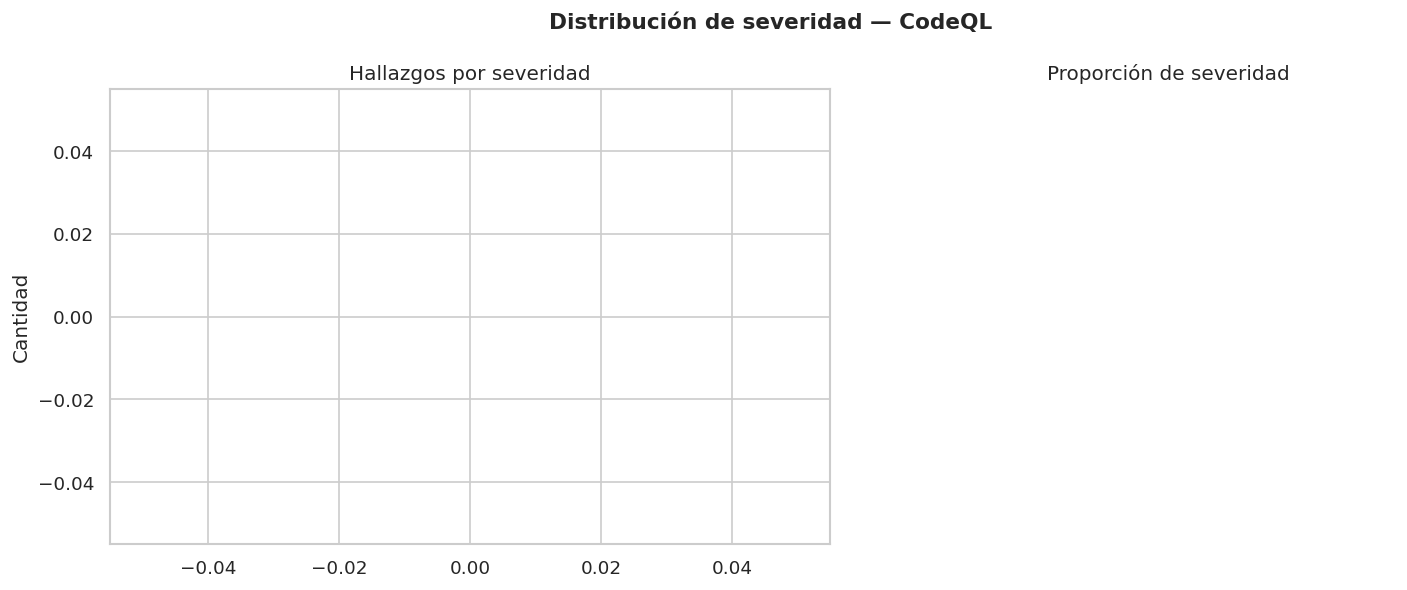

In [2]:
if not df.empty:
    sev_counts = df["severity"].value_counts().reindex(
        [s for s in SEV_ORDER if s in df["severity"].values], fill_value=0
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Barras
    bar_colors = [SEV_PALETTE.get(s, "#c7c7c7") for s in sev_counts.index]
    axes[0].bar(sev_counts.index, sev_counts.values, color=bar_colors)
    axes[0].set_title("Hallazgos por severidad")
    axes[0].set_ylabel("Cantidad")
    for i, v in enumerate(sev_counts.values):
        axes[0].text(i, v + 0.5, str(v), ha="center", fontweight="bold")

    # Torta
    axes[1].pie(sev_counts, labels=sev_counts.index,
                colors=[SEV_PALETTE.get(s, "#c7c7c7") for s in sev_counts.index],
                autopct="%1.1f%%", startangle=90)
    axes[1].set_title("Proporción de severidad")

    plt.suptitle("Distribución de severidad — CodeQL", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 2. Top 20 Reglas Más Frecuentes

Las reglas CodeQL identifican patrones concretos de vulnerabilidad (p.ej. `py/sql-injection`,
`js/xss`, `java/path-injection`). Ordenamos por frecuencia.

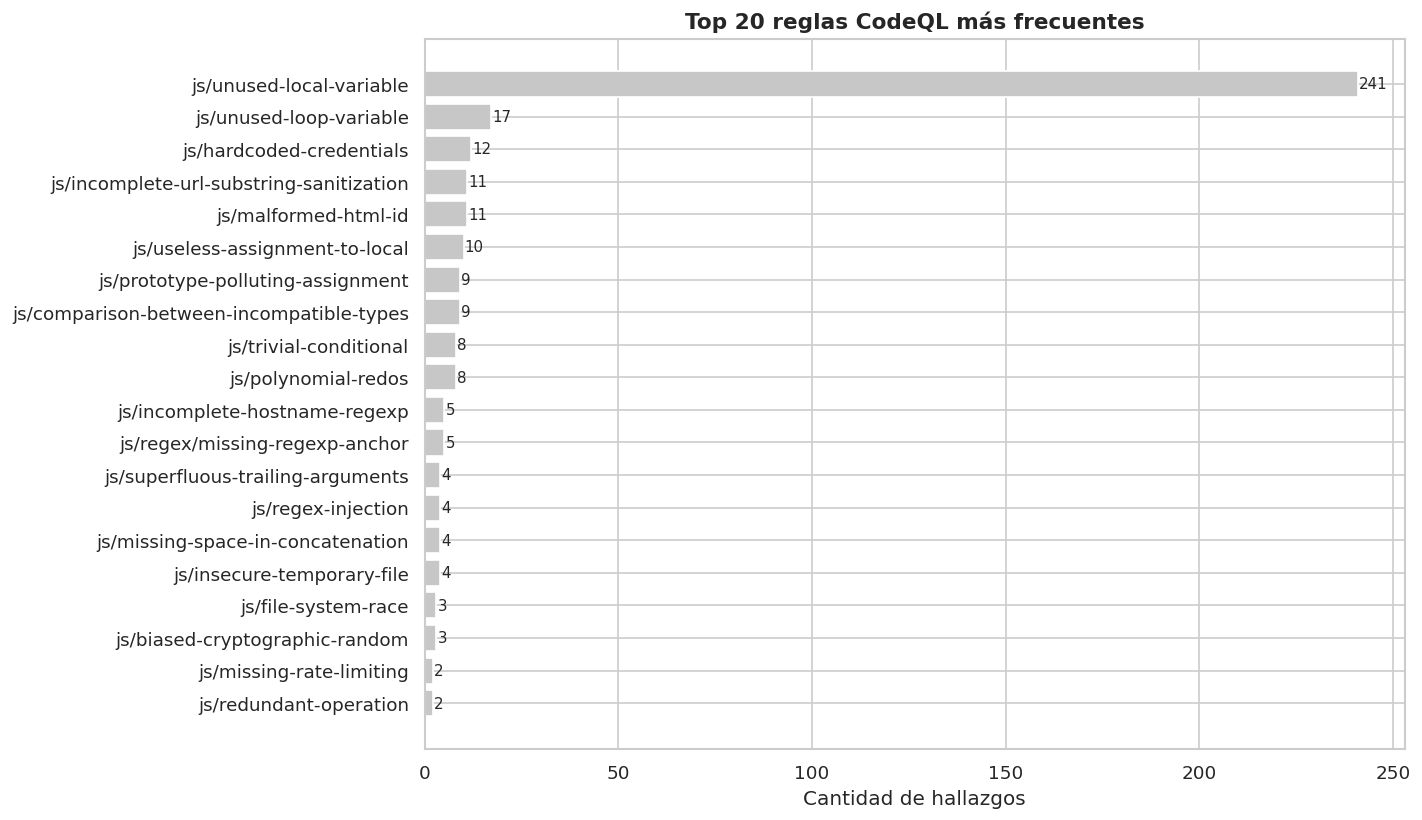


Top reglas con su nombre descriptivo:
                                 rule_id                                rule_name       severity
                     js/file-system-race                      js/file-system-race        warning
                  js/trivial-conditional                   js/trivial-conditional        warning
js/incomplete-url-substring-sanitization js/incomplete-url-substring-sanitization        warning
                js/missing-rate-limiting                 js/missing-rate-limiting        warning
                js/unused-local-variable                 js/unused-local-variable recommendation
                  js/redundant-operation                   js/redundant-operation        warning
                 js/unused-loop-variable                  js/unused-loop-variable          error
       js/superfluous-trailing-arguments        js/superfluous-trailing-arguments        warning
       js/prototype-polluting-assignment        js/prototype-polluting-assignment       

In [3]:
if not df.empty and "rule_id" in df.columns:
    rule_counts = df["rule_id"].value_counts().head(20)

    # Color por severidad de la regla más común
    rule_sev = df.groupby("rule_id")["severity"].agg(lambda x: x.mode()[0])
    bar_colors = [SEV_PALETTE.get(rule_sev.get(r, "unknown"), "#c7c7c7") for r in rule_counts.index]

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(rule_counts.index[::-1], rule_counts.values[::-1], color=bar_colors[::-1])
    ax.set_xlabel("Cantidad de hallazgos")
    ax.set_title("Top 20 reglas CodeQL más frecuentes", fontsize=13, fontweight="bold")
    for i, v in enumerate(rule_counts.values[::-1]):
        ax.text(v + 0.3, i, str(v), va="center", fontsize=9)
    plt.tight_layout()
    plt.show()

    print("\nTop reglas con su nombre descriptivo:")
    if "rule_name" in df.columns:
        rule_info = df.drop_duplicates("rule_id")[["rule_id", "rule_name", "severity"]]
        print(rule_info[rule_info["rule_id"].isin(rule_counts.index)].to_string(index=False))

## 3. Distribución de CWEs

Los CWE (Common Weakness Enumeration) permiten clasificar vulnerabilidades
independientemente de la herramienta. CodeQL etiqueta cada regla con CWEs relevantes.

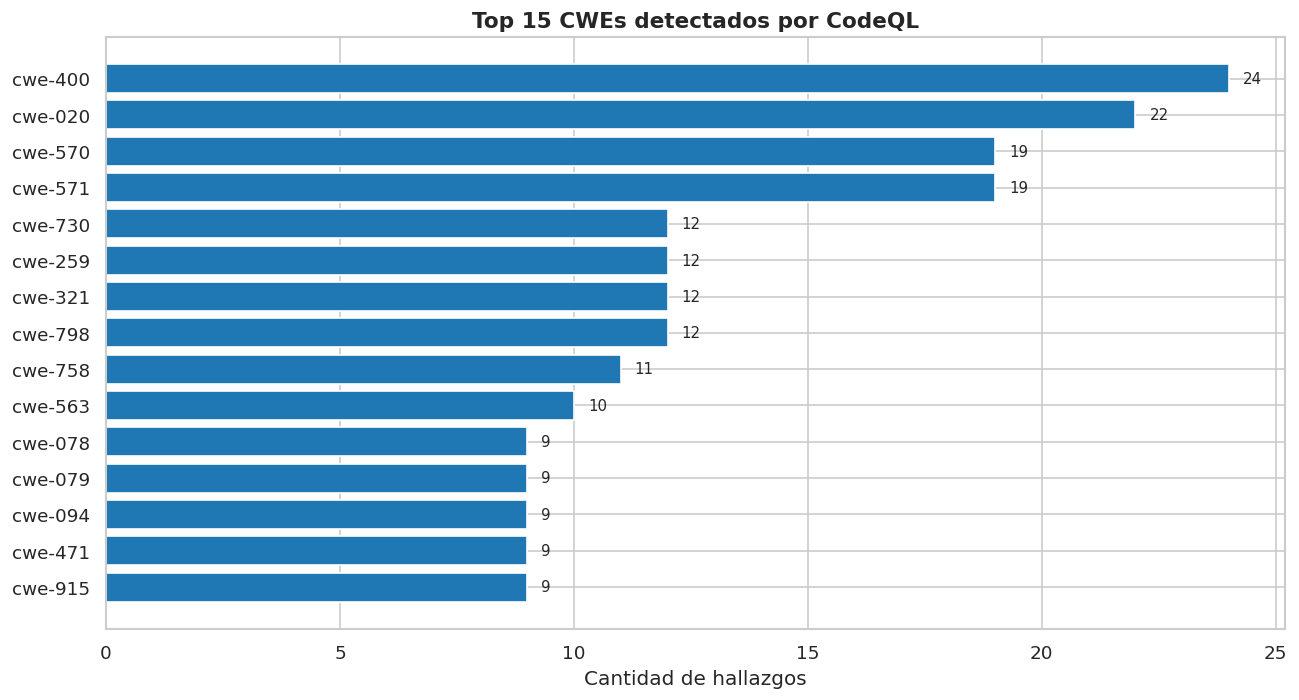

In [4]:
if not df.empty and "cwe" in df.columns:
    cwe_series = df["cwe"].dropna().explode()
    # Extraer solo el número CWE del tag 'external/cwe/cwe-NNN'
    cwe_series = cwe_series[cwe_series.astype(str).str.contains("cwe", na=False)]
    cwe_series = cwe_series.str.extract(r"(cwe-\d+)")[0].dropna()
    cwe_counts = cwe_series.value_counts().head(15)

    if cwe_counts.empty:
        print("No se encontraron etiquetas CWE en los hallazgos.")
    else:
        fig, ax = plt.subplots(figsize=(11, 6))
        ax.barh(cwe_counts.index[::-1], cwe_counts.values[::-1], color="#1f77b4")
        ax.set_xlabel("Cantidad de hallazgos")
        ax.set_title("Top 15 CWEs detectados por CodeQL", fontsize=13, fontweight="bold")
        for i, v in enumerate(cwe_counts.values[::-1]):
            ax.text(v + 0.3, i, str(v), va="center", fontsize=9)
        plt.tight_layout()
        plt.show()
else:
    print("No hay datos de CWE disponibles.")

## 4. Hallazgos por Repositorio y Severidad

Comparación entre repositorios usando un gráfico apilado por severidad.

TypeError: no numeric data to plot

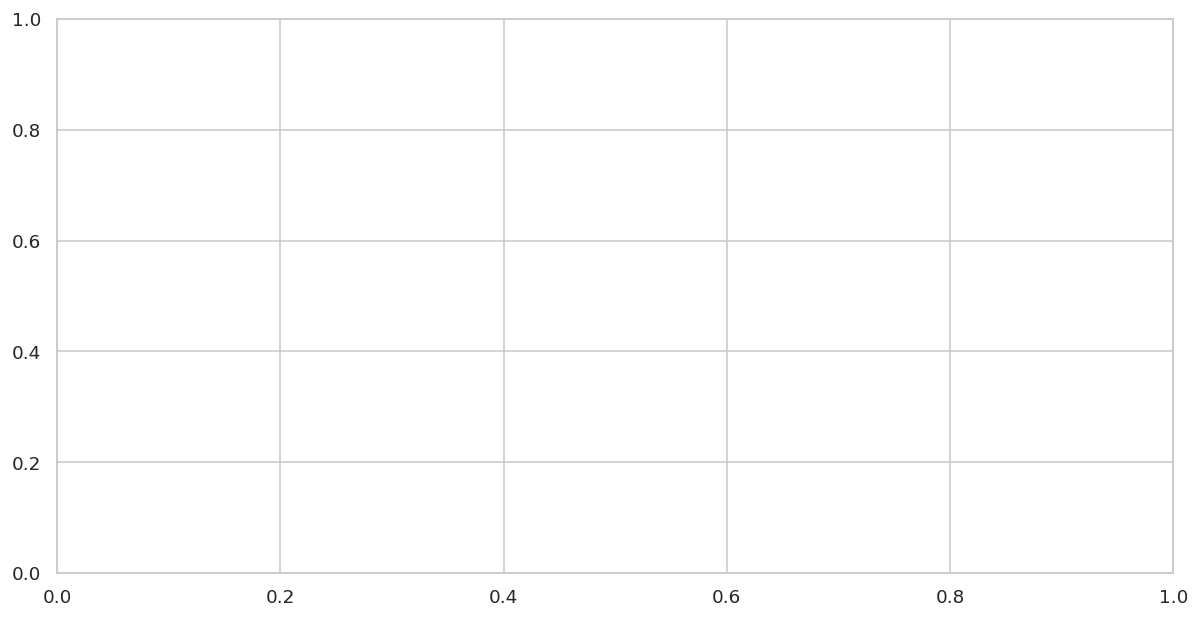

In [5]:
if not df.empty:
    pivot = df.groupby(["repo_name", "severity"]).size().unstack(fill_value=0)
    ordered_cols = [c for c in SEV_ORDER if c in pivot.columns]
    pivot["total"] = pivot[ordered_cols].sum(axis=1)
    pivot = pivot.sort_values("total", ascending=False).head(20)

    if len(pivot) > 0:
        fig, ax = plt.subplots(figsize=(12, max(6, len(pivot) * 0.5)))
        pivot[ordered_cols].plot(
            kind="barh", stacked=True, ax=ax,
            color=[SEV_PALETTE.get(c, "#c7c7c7") for c in ordered_cols]
        )
        ax.set_xlabel("Cantidad de hallazgos")
        ax.set_title("Hallazgos CodeQL por repositorio y severidad (top 20)",
                     fontsize=13, fontweight="bold")
        ax.legend(title="Severidad", bbox_to_anchor=(1.02, 1))
        plt.tight_layout()
        plt.show()

## 5. Archivos con Más Vulnerabilidades

Identifica los archivos que concentran más problemas de seguridad en toda la organización.

In [ ]:
if not df.empty and "file_path" in df.columns:
    file_counts = df["file_path"].dropna().value_counts().head(20)

    if not file_counts.empty:
        # Acortar paths largos
        labels = [p if len(p) <= 60 else "..." + p[-57:] for p in file_counts.index]

        fig, ax = plt.subplots(figsize=(12, 7))
        ax.barh(range(len(file_counts)), file_counts.values, color="#1f77b4")
        ax.set_yticks(range(len(file_counts)))
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel("Cantidad de hallazgos")
        ax.set_title("Top 20 archivos con más vulnerabilidades CodeQL",
                     fontsize=13, fontweight="bold")
        for i, v in enumerate(file_counts.values):
            ax.text(v + 0.2, i, str(v), va="center", fontsize=9)
        plt.tight_layout()
        plt.show()

## 6. Lenguajes Analizados

Distribución de repositorios por lenguaje de programación analizado con CodeQL.

In [ ]:
if not scans.empty and "language" in scans.columns:
    lang_counts = scans["language"].dropna().value_counts()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(lang_counts.index, lang_counts.values, color="#17becf")
    ax.set_ylabel("Repositorios analizados")
    ax.set_title("Distribución de lenguajes analizados por CodeQL",
                 fontsize=13, fontweight="bold")
    for i, v in enumerate(lang_counts.values):
        ax.text(i, v + 0.2, str(v), ha="center", fontweight="bold")
    plt.tight_layout()
    plt.show()

    print("\nHallazgos promedio por lenguaje:")
    if not df.empty:
        lang_map = scans.set_index("repo_id")["language"].to_dict()
        df_lang = df.copy()
        df_lang["language"] = df_lang["repo_id"].map(lang_map)
        print(df_lang.groupby("language").size().rename("hallazgos").to_string())